# ML Pipeline for AI Real Estate Agent

This notebook trains the sklearn pipeline, evaluates model performance, saves production artifacts, and runs Stage 1 prompt versioning experiments.

Dataset source: Kaggle Ames Housing (`house-prices-advanced-regression-techniques/train.csv`).

In [27]:
import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from pydantic import ValidationError

import google.generativeai as genai

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Ensure notebook can import the app package when run from notebooks/.
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.prompts import STAGE1_PROMPT_V1, STAGE1_PROMPT_V2
from app.schemas import HouseFeatures

## Section 1: EDA

In [28]:
DATA_PATH = Path("../house-prices-advanced-regression-techniques/train.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset at {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False).head(30))

df.head()

Shape: (1460, 81)

Dtypes:
 Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Null counts:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
LandSlope          0
LotConfig          0
Condition1         0
LandContour        0
LotShape           0
Street             0
LotArea            0
MSSubClass         0
dtype: int64


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


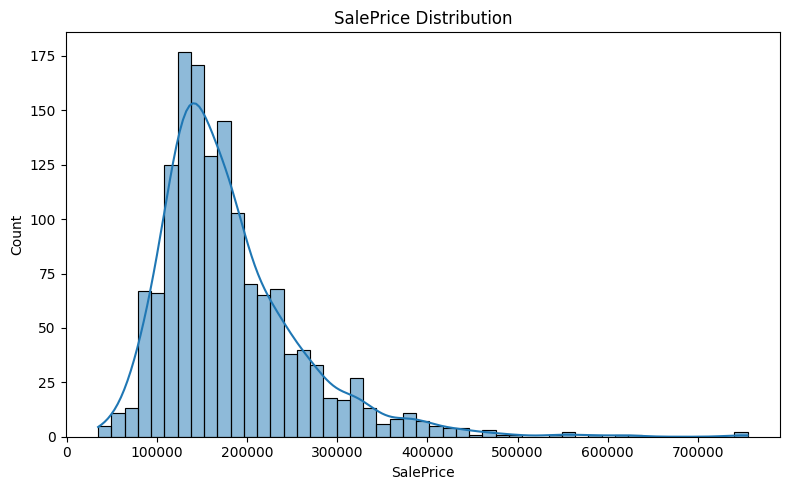

Top correlations with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice")
plt.tight_layout()
plt.show()

corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print("Top correlations with SalePrice:")
print(corr.head(15))

## Section 2: Feature Selection

In [30]:
FEATURE_COLUMNS = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "HalfBath",
    "TotalBsmtSF",
    "GarageArea",
    "OverallQual",
    "YearBuilt",
    "Neighborhood",
    "HouseStyle",
]
TARGET_COLUMN = "SalePrice"

missing_required = [c for c in FEATURE_COLUMNS + [TARGET_COLUMN] if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns in dataset: {missing_required}")

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].astype(float).copy()

print("Feature columns fixed contract:", FEATURE_COLUMNS)
print("Target column:", TARGET_COLUMN)

Feature columns fixed contract: ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'HalfBath', 'TotalBsmtSF', 'GarageArea', 'OverallQual', 'YearBuilt', 'Neighborhood', 'HouseStyle']
Target column: SalePrice


## Section 3: Three-Way Split

In [31]:
# First split: train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

# Second split on temp: validation 15%, test 15% (half of temp each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (1022, 10) y_train: (1022,)
X_val: (219, 10) y_val: (219,)
X_test: (219, 10) y_test: (219,)


## Section 4: Preprocessing Pipeline

In [32]:
numeric_features = [
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "HalfBath",
    "TotalBsmtSF",
    "GarageArea",
    "YearBuilt",
]
ordinal_features = ["OverallQual"]
nominal_features = ["Neighborhood", "HouseStyle"]

# Numerical pipeline: median imputation handles skew/outliers, then scaling standardizes units.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Ordinal pipeline: mode imputation plus explicit ordered encoding (1..10) prevents accidental reordering.
ordinal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(categories=[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]),
        ),
    ]
)

# Nominal pipeline: mode imputation and one-hot with unknown-ignore for unseen labels from Stage 1 output.
nominal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("nom", nominal_transformer, nominal_features),
    ]
)

print("Preprocessor configured.")

Preprocessor configured.


## Section 5: Model Comparison

In [33]:
models = {
    "Ridge": Ridge(alpha=10.0),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = []
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    # fit on train only - no leakage
    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    val_pred = pipe.predict(X_val)

    # sklearn>=1.8 removed the 'squared' argument from mean_squared_error.
    train_rmse = float(np.sqrt(mean_squared_error(y_train, train_pred)))
    val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    results.append(
        {
            "model": name,
            "train_rmse": train_rmse,
            "train_r2": train_r2,
            "val_rmse": val_rmse,
            "val_r2": val_r2,
        }
    )
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("val_rmse")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]
print(f"\nBest model by validation RMSE: {best_model_name}")

           model   train_rmse  train_r2     val_rmse   val_r2
    RandomForest 13034.345000  0.971772 25994.326901 0.892421
GradientBoosting 15770.491206  0.958677 27556.017836 0.879107
           Ridge 35087.046271  0.795450 28401.261389 0.871576

Best model by validation RMSE: RandomForest


Model choice justification:

RandomForest is selected because it achieved the best validation RMSE (25,994.33), outperforming GradientBoosting (27,556.02) and Ridge (28,401.26), while also maintaining the highest validation R² (0.8924). That pattern indicates better generalization on unseen validation data for this feature set and preprocessing design. The final one-time test evaluation remained strong (RMSE 27,491.42; R² 0.9007), confirming that the validation winner was a stable deployment choice rather than a split-specific fluke.

## Section 6: Test Set Evaluation

In [34]:
# This should be executed once after model selection is finalized.
test_pred = best_pipeline.predict(X_test)
test_rmse = float(np.sqrt(mean_squared_error(y_test, test_pred)))
test_r2 = r2_score(y_test, test_pred)

print(f"Test RMSE: {test_rmse:,.2f}")
print(f"Test R2: {test_r2:.4f}")
print("Final evaluation complete. Do not rerun this cell.")

Test RMSE: 27,491.42
Test R2: 0.9007
Final evaluation complete. Do not rerun this cell.


## Section 7: Serialization + Summary Stats

In [35]:
model_dir = Path("../app/model")
model_dir.mkdir(parents=True, exist_ok=True)

# fit on train only - no leakage
best_pipeline.fit(X_train, y_train)
joblib.dump(best_pipeline, model_dir / "pipeline.joblib")

train_stats = {
    "median_price": float(np.median(y_train)),
    "mean_price": float(np.mean(y_train)),
    "price_10th_percentile": float(np.percentile(y_train, 10)),
    "price_90th_percentile": float(np.percentile(y_train, 90)),
    "price_std": float(np.std(y_train)),
}

with open(model_dir / "train_stats.json", "w", encoding="utf-8") as f:
    json.dump(train_stats, f, indent=2)

print("Saved:", model_dir / "pipeline.joblib")
print("Saved:", model_dir / "train_stats.json")
print(train_stats)

Saved: ..\app\model\pipeline.joblib
Saved: ..\app\model\train_stats.json
{'median_price': 165000.0, 'mean_price': 181312.6927592955, 'price_10th_percentile': 106500.0, 'price_90th_percentile': 277450.0, 'price_std': 77579.4783941699}


## Section 8: Prompt Versioning Experiments

In [36]:
load_dotenv("../.env", override=True)
key = os.getenv("GEMINI_API_KEY", "").strip().strip('"').strip("'")
if not key or key == "YOUR_GEMINI_API_KEY_HERE":
    raise RuntimeError("Set GEMINI_API_KEY in ../.env before running this section.")

genai.configure(api_key=key)
gemini = genai.GenerativeModel("gemini-2.5-flash")

queries = {
    "A": "3 bedroom house in a good neighborhood with a 2 car garage",
    "B": "small starter home, 1 bath, older construction",
    "C": "luxury property, large living area, excellent quality, finished basement",
}

prompt_versions = {
    "STAGE1_PROMPT_V1": STAGE1_PROMPT_V1,
    "STAGE1_PROMPT_V2": STAGE1_PROMPT_V2,
}

rows = []
required_feature_keys = set(FEATURE_COLUMNS)

for version_name, prompt_template in prompt_versions.items():
    for query_name, query_text in queries.items():
        raw_output = ""
        parsed = {}
        validation_passed = False

        try:
            # Use replace instead of .format because the prompt contains raw JSON braces.
            rendered_prompt = prompt_template.replace("{query}", query_text)
            raw_output = gemini.generate_content(rendered_prompt).text
            cleaned = raw_output.replace("```json", "").replace("```", "").strip()
            parsed = json.loads(cleaned)

            feature_only = {k: parsed.get(k) for k in FEATURE_COLUMNS}
            HouseFeatures(**feature_only)
            validation_passed = True
        except (json.JSONDecodeError, ValidationError, Exception):
            validation_passed = False

        parsed_keys = set(parsed.keys()) if isinstance(parsed, dict) else set()
        feature_keys_present = parsed_keys.intersection(required_feature_keys)
        missing_keys_exact = sorted(required_feature_keys - feature_keys_present)
        key_match_ok = feature_keys_present == required_feature_keys

        extracted_fields = parsed.get("extracted_fields", []) if isinstance(parsed, dict) else []
        missing_fields = parsed.get("missing_fields", []) if isinstance(parsed, dict) else list(FEATURE_COLUMNS)

        rows.append(
            {
                "version": version_name,
                "query": query_name,
                "raw_output": raw_output,
                "validation_passed": validation_passed,
                "key_match_ok": key_match_ok,
                "extracted_fields": extracted_fields,
                "missing_fields": missing_fields,
                "missing_exact_keys": missing_keys_exact,
            }
        )

experiments_df = pd.DataFrame(rows)
experiments_df

,version,query,raw_output,validation_passed,key_match_ok,extracted_fields,missing_fields,missing_exact_keys
0,STAGE1_PROMPT_V1,A,"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": 3,\...",True,True,"[BedroomAbvGr, GarageArea]","[GrLivArea, FullBath, HalfBath, TotalBsmtSF, O...",[]
1,STAGE1_PROMPT_V1,B,"```json\n{\n ""GrLivArea"": null,\n ""BedroomAb...",True,True,[FullBath],"[GrLivArea, BedroomAbvGr, HalfBath, TotalBsmtS...",[]
2,STAGE1_PROMPT_V1,C,"```json\n{\n ""GrLivArea"": null,\n ""BedroomAb...",True,True,[OverallQual],"[GrLivArea, BedroomAbvGr, FullBath, HalfBath, ...",[]
3,STAGE1_PROMPT_V2,A,"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": 3,\...",True,True,"[BedroomAbvGr, GarageArea, Neighborhood]","[GrLivArea, FullBath, HalfBath, TotalBsmtSF, O...",[]
4,STAGE1_PROMPT_V2,B,"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": nul...",True,True,"[FullBath, OverallQual]","[GrLivArea, BedroomAbvGr, HalfBath, TotalBsmtS...",[]
5,STAGE1_PROMPT_V2,C,"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": nul...",True,True,[OverallQual],"[GrLivArea, BedroomAbvGr, FullBath, HalfBath, ...",[]


In [39]:
experiments_df = experiments_df.assign(
    extracted_count=experiments_df["extracted_fields"].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )
)

summary = (
    experiments_df.groupby("version")
    .agg(
        total_runs=("version", "count"),
        valid_json_schema=("validation_passed", "sum"),
        exact_key_match=("key_match_ok", "sum"),
        avg_extracted_fields=("extracted_count", "mean"),
    )
    .reset_index()
)

summary = summary.assign(
    score=summary["valid_json_schema"] + summary["exact_key_match"]
)

# Primary criterion: valid schema + exact key contract.
# Tie-breaker: prefer the prompt that extracts more usable fields.
summary_sorted = summary.sort_values(["score", "avg_extracted_fields"], ascending=[False, False])
winner = summary_sorted.iloc[0]["version"]

print("Prompt comparison summary:")
print(summary_sorted.to_markdown(index=False))
print(f"\nWinner: {winner}")
print(
    "Winner selection rule: maximize valid schema parses + exact feature-key contract matches "
    "across Query A/B/C; break ties by average extracted non-null fields."
)

experiments_df = experiments_df.assign(
    raw_output_preview=experiments_df["raw_output"].astype(str).str.slice(0, 200)
)
experiments_df[[
    "version",
    "query",
    "validation_passed",
    "key_match_ok",
    "extracted_fields",
    "extracted_count",
    "missing_fields",
    "missing_exact_keys",
    "raw_output_preview",
]]

Prompt comparison summary:
| version          |   total_runs |   valid_json_schema |   exact_key_match |   avg_extracted_fields |   score |
|:-----------------|-------------:|--------------------:|------------------:|-----------------------:|--------:|
| STAGE1_PROMPT_V2 |            3 |                   3 |                 3 |                2       |       6 |
| STAGE1_PROMPT_V1 |            3 |                   3 |                 3 |                1.33333 |       6 |

Winner: STAGE1_PROMPT_V2
Winner selection rule: maximize valid schema parses + exact feature-key contract matches across Query A/B/C; break ties by average extracted non-null fields.


,version,query,validation_passed,key_match_ok,extracted_fields,extracted_count,missing_fields,missing_exact_keys,raw_output_preview
0,STAGE1_PROMPT_V1,A,True,True,"[BedroomAbvGr, GarageArea]",2,"[GrLivArea, FullBath, HalfBath, TotalBsmtSF, O...",[],"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": 3,\..."
1,STAGE1_PROMPT_V1,B,True,True,[FullBath],1,"[GrLivArea, BedroomAbvGr, HalfBath, TotalBsmtS...",[],"```json\n{\n ""GrLivArea"": null,\n ""BedroomAb..."
2,STAGE1_PROMPT_V1,C,True,True,[OverallQual],1,"[GrLivArea, BedroomAbvGr, FullBath, HalfBath, ...",[],"```json\n{\n ""GrLivArea"": null,\n ""BedroomAb..."
3,STAGE1_PROMPT_V2,A,True,True,"[BedroomAbvGr, GarageArea, Neighborhood]",3,"[GrLivArea, FullBath, HalfBath, TotalBsmtSF, O...",[],"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": 3,\..."
4,STAGE1_PROMPT_V2,B,True,True,"[FullBath, OverallQual]",2,"[GrLivArea, BedroomAbvGr, HalfBath, TotalBsmtS...",[],"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": nul..."
5,STAGE1_PROMPT_V2,C,True,True,[OverallQual],1,"[GrLivArea, BedroomAbvGr, FullBath, HalfBath, ...",[],"{\n ""GrLivArea"": null,\n ""BedroomAbvGr"": nul..."
